## Random Forest Agent

This notebook mirrors `src/04_random_forest.py` so you can:

- **Train** a random forest algorithm on all `*.jsonl` files in a data folder (state → action).
- **Clean** your training data so you won't have data leakage or duplicates.
- **Build** custom features that will enable your agent to perform better.
- **Compare** the model to a few recorded frames before running the live Godot loop.

**Recording your own sessions:** run `src/02_record_gameplay.py` (e.g. `python src/02_record_gameplay.py` from the repo root) to record gameplay as `.jsonl` files. You need those recordings to train this kind of imitation-learning agent; save or copy them under `DATA_DIR` (top-level `*.jsonl` only).

Observation layout is the same as elsewhere: see `00_data_exploration.ipynb`. Training only uses top-level `*.jsonl` in the chosen directory (not subfolders); point `DATA_DIR` at a folder that contains your recordings.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, "..")
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from processing.frame_visualizer import FrameVisualizer
from utils import load_observations_by_session, setup_environment

In [43]:
def plot_state_duplicates(total_data, unique_count):
    import matplotlib.pyplot as plt

    duplicate_count = total_data - unique_count
    plt.figure(figsize=(6, 6))
    plt.pie(
        [unique_count, duplicate_count],
        labels=["Unique", "Duplicates"],
        autopct="%1.1f%%",
        startangle=90,
        explode=(0, 0.05),
    )
    plt.title(f"Dataset Deduplication (total={total_data})")
    plt.axis("equal")
    plt.show()

def plot_action_distribution(actions):
    plt.hist(actions, bins=np.arange(-0.5, max(actions) + 1.5, 1), rwidth=0.8)
    plt.xlabel("Action")
    plt.ylabel("Frequency")
    plt.title("Distribution of Actions in the Dataset")
    plt.xticks(np.arange(max(actions) + 1))
    plt.show()

In [44]:
data_path = "../data/"
all_data = {}

for i, data_file in enumerate(Path(data_path).glob("*.jsonl")):
    observations_by_session = load_observations_by_session(data_file)
    for session_id, all_steps in observations_by_session.items():
        all_data[f"{i}_{session_id}"] = all_steps

We need to remove duplicates from our data because we don't want to:
- prevent train/validation leakage from repeated states
- remove conflicting labels for identical inputs, so the model learns consistent behavior

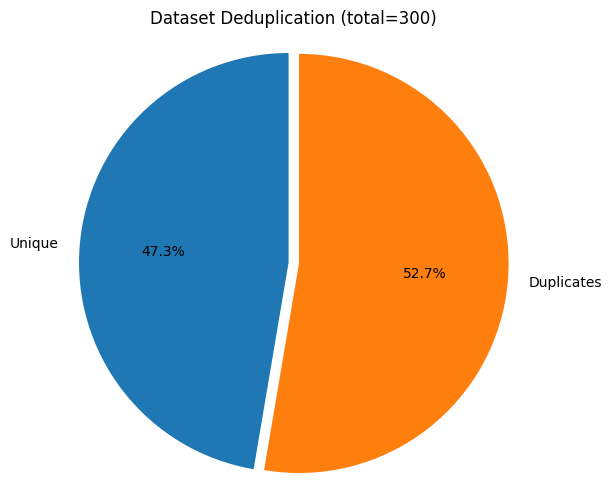

In [59]:
import hashlib
from collections import defaultdict, Counter

grouped = defaultdict(lambda: {"state": None, "actions": []})

# The code looks complicated because we want to remove duplicates
total_samples = 0
for all_steps in all_data.values():
    for step in all_steps:
        state = step["state"]
        state_hash = hashlib.sha256(str(state).encode()).hexdigest()

        if grouped[state_hash]["state"] is None:
            grouped[state_hash]["state"] = state
        grouped[state_hash]["actions"].append(step["action"])
        total_samples += 1

# while also keeping the most common action for each state
aggregated_data = []
for item in grouped.values():
    action_counts = Counter(item["actions"])
    majority_action = action_counts.most_common(1)[0][0]

    aggregated_data.append({
        "state": item["state"],
        "action": majority_action,
    })

plot_state_duplicates(i, len(aggregated_data))

The issue we have right now is that there are more samples with action 0 (don't jump) than with 1 (jump)

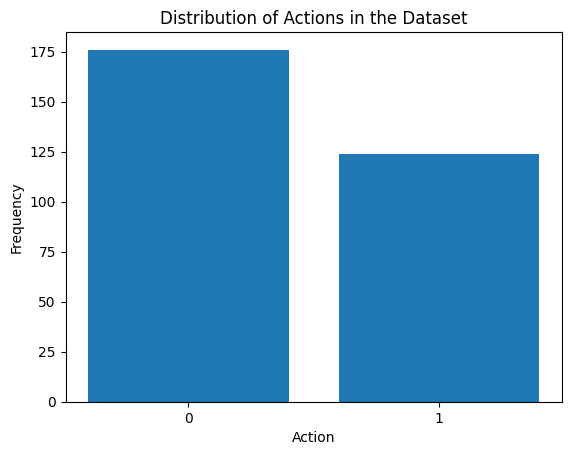

In [60]:
actions = []
for session_id, all_steps in all_data.items():
    for step in all_steps:
        actions.append(step["action"])

plot_action_distribution(actions)

In this case, we'll need to compute a class-weight ratio for training.
This ratio will tell us:
  - if the model fails to release the jump button (action = 0), we will tax the model normally (error * 1.0)
  - if the model fails to press the jump button (action = 1), we will tax the model harder (error * ratio)

We do this to compesate for class imbalances, since during a playthrough we usually have our button off the space button more than we actually press the button.

In [61]:
nb_ones = sum(actions)
nb_zeros = len(actions) - nb_ones

ratio = 1.0
if nb_ones != 0:
    ratio = nb_zeros / nb_ones

class_weights = {0: 1.0, 1: ratio}
class_weights

{0: 1.0, 1: 1.4193548387096775}

In [62]:
def load_training_xy(data):
    X, y = [], []
    for step in data:
        X.append(step["state"])
        y.append(step["action"])

    return X, y

X, y = load_training_xy(aggregated_data)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    max_depth=10,
    class_weight=class_weights
)

model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)

print(f"Random forest accuracy (hold-out): {accuracy:.2f}")

Random forest accuracy (hold-out): 0.83


In [66]:
def agent_brain(model, step_count, observation, done=False):
    # You need to press jump on the first frame to start walking.
    if step_count == 0 or done:
        return [1]

    pred = model.predict([observation])[0]
    return [int(pred)]


env = setup_environment()
obs = env.reset()
nb_agents = len(obs["obs"])

step_count = 0
done = [False] * nb_agents
while True:
    actions = [
        agent_brain(model, step_count, obs["obs"][i], done[i]) for i in range(nb_agents)
    ]
    actions = np.array(actions, dtype=np.int64)
    obs, reward, done, info = env.step(actions)
    if any(done):
        break
    step_count += 1

env.close()

python-dotenv could not parse statement starting at line 2
python-dotenv could not parse statement starting at line 3


Loaded environment variables from /Users/statieg/Personal/PLaiGROUND/src/.config
None
No game binary has been provided, please press PLAY in the Godot editor
waiting for remote GODOT connection on port 11008
connection established
action space [{'jump': {'size': 1, 'action_type': 'discrete'}}]
observation space [{'obs': {'size': [57], 'space': 'box'}}]
close message sent


Now we may also want to play around with some custom features

In [67]:
def compute_can_jump(sensor_values, session_info):
    """
    The player can jump if:
      - After jumping, it released the jump button and touched the floor
      - After jumping, it released the jump button and has a powerup
    """
    on_floor = bool(sensor_values["on_floor"])
    has_powerup = bool(sensor_values["has_powerup"])
    jump_pressed = int(session_info["prev_action"]) == 1  # jump action id
    
    return float(has_powerup or (on_floor and not jump_pressed))

In [68]:
def compute_wall_sensors(grid, wall_index):
    wall_distance_sensors = []
    
    right_wall_distance = 1
    for i, right_cells in enumerate([grid[3][3], grid[3][4], grid[3][5], grid[3][6]]):
        if right_cells == wall_index:
            right_wall_distance = i * 0.25
            break
    wall_distance_sensors.append(right_wall_distance)

    left_wall_distance = 1
    for i, left_cells in enumerate([grid[3][3], grid[3][2], grid[3][1], grid[3][0]]):
        if left_cells == wall_index:
            left_wall_distance = i * 0.25
            break
    wall_distance_sensors.append(left_wall_distance)
    
    up_wall_distance = 1
    for i, up_cells in enumerate([grid[3][3], grid[2][3], grid[1][3], grid[0][3]]):
        if up_cells == wall_index:
            up_wall_distance = i * 0.25
            break
    wall_distance_sensors.append(up_wall_distance)

    down_wall_distance = 1
    for i, down_cells in enumerate([grid[3][3], grid[4][3], grid[5][3], grid[6][3]]):
        if down_cells == wall_index:
            down_wall_distance = i * 0.25
            break
    wall_distance_sensors.append(down_wall_distance)

    diagonal_up_left_wall_distance = 1
    for i, up_left_cells in enumerate([grid[3][3], grid[2][2], grid[1][1], grid[0][0]]):
        if up_left_cells == wall_index:
            diagonal_up_left_wall_distance = i * 0.25
            break
    wall_distance_sensors.append(diagonal_up_left_wall_distance)

    diagonal_up_right_wall_distance = 1
    for i, up_right_cells in enumerate([grid[3][3], grid[2][4], grid[1][5], grid[0][6]]):
        if up_right_cells == wall_index:
            diagonal_up_right_wall_distance = i * 0.25
            break
    wall_distance_sensors.append(diagonal_up_right_wall_distance)

    diagonal_down_left_wall_distance = 1
    for i, down_left_cells in enumerate([grid[3][3], grid[4][2], grid[5][1], grid[6][0]]):
        if down_left_cells == wall_index:
            diagonal_down_left_wall_distance = i * 0.25
            break
    wall_distance_sensors.append(diagonal_down_left_wall_distance)

    diagonal_down_right_wall_distance = 1
    for i, down_right_cells in enumerate([grid[3][3], grid[4][4], grid[5][5], grid[6][6]]):
        if down_right_cells == wall_index:
            diagonal_down_right_wall_distance = i * 0.25
            break
    wall_distance_sensors.append(diagonal_down_right_wall_distance)

    return wall_distance_sensors

In [78]:
def engineer_features(observation, session_info=None):
    visualizer = FrameVisualizer()
    parsed_obs = visualizer.parse_observation(observation)
    grid = parsed_obs["grid"]
    sensor_values = parsed_obs["sensor_values"]
    sensors = list(sensor_values.values())

    # Create features for the player's ability to jump
    can_jump = compute_can_jump(sensor_values, session_info)

    # Create features for walls around the agent
    wall_index = visualizer.get_class_index("Wall")
    wall_distance_sensors = compute_wall_sensors(grid, wall_index)

    return [can_jump] + wall_distance_sensors + sensors

Update training data to also use the features we created

In [79]:
def load_training_xy_with_features(data):
    X, y = [], []
    session_info = {"prev_action": 0}
    for step in data:
        X.append(engineer_features(step["state"], session_info))
        y.append(step["action"])
        session_info["prev_action"] = step["action"]
    return X, y

X, y = load_training_xy_with_features(aggregated_data)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [80]:
model = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    max_depth=10,
    class_weight=class_weights
)

model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)

print(f"Random forest accuracy (hold-out): {accuracy:.2f}")

Random forest accuracy (hold-out): 0.79


In [81]:
def agent_brain(model, step_count, observation, session_info, done=False):
    # You need to press jump on the first frame to start walking.
    if step_count == 0 or done:
        return [1]

    engineered_features = engineer_features(observation, session_info)
    pred = model.predict([engineered_features])[0]
    return [int(pred)]


env = setup_environment()
obs = env.reset()
nb_agents = len(obs["obs"])

step_count = 0
session_infos = [{"prev_action": 0} for i in range(nb_agents)]
done = [False] * nb_agents
while True:
    actions = [
        agent_brain(model, step_count, obs["obs"][i], session_infos[i], done[i]) for i in range(nb_agents)
    ]
    actions = np.array(actions, dtype=np.int64)
    obs, reward, done, info = env.step(actions)

    # Update the session info for each agent
    for i, action in enumerate(actions):
        session_infos[i]["prev_action"] = action[0]

    if any(done):
        break
    step_count += 1

env.close()

python-dotenv could not parse statement starting at line 2
python-dotenv could not parse statement starting at line 3


Loaded environment variables from /Users/statieg/Personal/PLaiGROUND/src/.config
None
No game binary has been provided, please press PLAY in the Godot editor
waiting for remote GODOT connection on port 11008
connection established
action space [{'jump': {'size': 1, 'action_type': 'discrete'}}]
observation space [{'obs': {'size': [57], 'space': 'box'}}]
close message sent
